In [1]:
# Step 1: Create 10 sentences (3 topics)

sentences = [
    # Cricket (3+)
    "The batsman scored a century in the match.",
    "The bowler took three wickets in one over.",
    "The team won the cricket match by 5 runs.",

    # Cooking (3+)
    "I cooked pasta with fresh vegetables.",
    "The recipe requires baking the cake for 30 minutes.",
    "She added spices to enhance the flavor of the dish.",

    # Cybersecurity (3+)
    "Cybersecurity protects systems from digital attacks.",
    "Strong passwords help prevent unauthorized access.",
    "Encryption is used to secure sensitive data.",

    # Extra (10th sentence)
    "Hackers try to exploit vulnerabilities in systems."
]

print("Total sentences:", len(sentences))

Total sentences: 10


In [2]:
# Step 2: Install required library
!pip install sentence-transformers

In [3]:
# Step 3: Generate embeddings

from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convert sentences to embeddings
embeddings = model.encode(sentences)

print("Shape of embeddings:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Shape of embeddings: (10, 384)


In [4]:
# Step 4: Compute cosine similarity

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (10, 10)


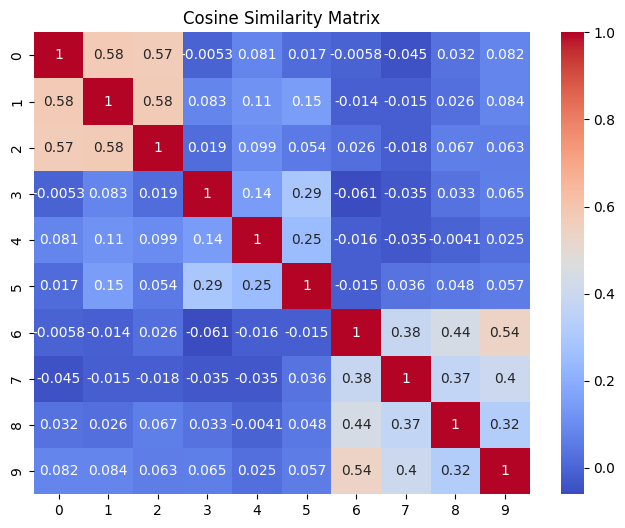

In [5]:
# Step 5: Display heatmap

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')

plt.title("Cosine Similarity Matrix")
plt.show()

In [9]:
# Step 6: Find top 2 similar sentences (exclude self properly)

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get sorted indices (highest first)
sorted_indices = similarities.argsort()[::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

results = []

for idx in sorted_indices:
    # Skip the highest similarity (self-match)
    if similarities[idx] > 0.95:
        continue

    results.append(idx)

    if len(results) == 2:
        break

for idx in results:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the match.
Similarity Score: 0.5611

Sentence: The team won the cricket match by 5 runs.
Similarity Score: 0.5585

